In [3]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print("Libraries imported successfully!")

Libraries imported successfully!


# Loan Default Risk Analysis

## Notebook 1 : Data Understanding

### Objective

The objective of this notebook is to understand the dataset before performing exploratory data analysis and machine learning.

In [4]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("../data/raw/Loan_default.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
categorical_cols = [
    "Education",
    "EmploymentType",
    "MaritalStatus",
    "HasMortgage",
    "HasDependents",
    "LoanPurpose",
    "HasCoSigner"
]

for col in categorical_cols:
    print(f"\n{col}:")
    print(sorted(df[col].unique()))


Education:
["Bachelor's", 'High School', "Master's", 'PhD']

EmploymentType:
['Full-time', 'Part-time', 'Self-employed', 'Unemployed']

MaritalStatus:
['Divorced', 'Married', 'Single']

HasMortgage:
['No', 'Yes']

HasDependents:
['No', 'Yes']

LoanPurpose:
['Auto', 'Business', 'Education', 'Home', 'Other']

HasCoSigner:
['No', 'Yes']


In [3]:
# Display first five rows

df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [4]:
# ==========================================
# Dataset Information
# ==========================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     255347 non-null  str    
 16  HasCoSigner     255347 non-null  str    
 17  Default         25534

## Observation

- The dataset contains **255,347 observations** and **18 variables**.
- Both numerical and categorical variables are present.
- The target variable is **Default**, indicating a binary classification problem.
- The data types appear appropriate for the respective variables.
- No obvious missing values were observed (we will verify this explicitly later).

In [5]:
# ==========================================
# Statistical Summary of Numerical Variables
# ==========================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,255347.0,43.498306,14.990258,18.0,31.00,43.00,56.00,69.0
Income,255347.0,82499.304597,38963.013729,15000.0,48825.50,82466.00,116219.00,149999.0
LoanAmount,255347.0,127578.865512,70840.706142,5000.0,66156.00,127556.00,188985.00,249999.0
CreditScore,255347.0,574.264346,158.903867,300.0,437.00,574.00,712.00,849.0
MonthsEmployed,255347.0,59.541976,34.643376,0.0,30.00,60.00,90.00,119.0
NumCreditLines,255347.0,2.501036,1.117018,1.0,2.00,2.00,3.00,4.0
InterestRate,255347.0,13.492773,6.636443,2.0,7.77,13.46,19.25,25.0
LoanTerm,255347.0,36.025894,16.969330,12.0,24.00,36.00,48.00,60.0
DTIRatio,255347.0,0.500212,0.230917,0.1,0.30,0.50,0.70,0.9
Default,255347.0,0.116128,0.320379,0.0,0.00,0.00,0.00,1.0


## Observation

- Descriptive statistics provide a summary of all numerical variables.
- The dataset contains complete observations for the numerical features.
- The mean, median, and quartiles help us understand the distribution of each variable.
- Minimum and maximum values will be useful for identifying potential outliers during EDA.

In [6]:
# ==========================================
# Summary of Categorical Variables
# ==========================================

df.describe(include="object").T

,count,unique,top,freq
LoanID,255347,255347,I38PQUQS96,1
Education,255347,4,Bachelor's,64366
EmploymentType,255347,4,Part-time,64161
MaritalStatus,255347,3,Married,85302
HasMortgage,255347,2,Yes,127677
HasDependents,255347,2,Yes,127742
LoanPurpose,255347,5,Business,51298
HasCoSigner,255347,2,Yes,127701


## Observation

- The dataset contains several categorical variables describing borrower demographics and loan characteristics.
- The summary provides the number of unique categories and the most frequently occurring category for each variable.
- No missing values are observed in the categorical variables.
- These variables will later be encoded before training machine learning models.

In [7]:
# ==========================================
# Check Missing Values
# ==========================================

df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

## Observation

- Missing values were checked for all variables.
- No missing values were found in the dataset.
- Therefore, no imputation or missing value treatment is required before model development.

In [8]:
# ==========================================
# Check Duplicate Records
# ==========================================

duplicates = df.duplicated().sum()

print("Number of Duplicate Records:", duplicates)

Number of Duplicate Records: 0


## Observation

- No duplicate records were found in the dataset.
- Therefore, duplicate removal is not required.

In [12]:
# ==========================================
# Distribution of Target Variable
# ==========================================

df["Default"].value_counts()

Default
0    225694
1     29653
Name: count, dtype: int64

In [13]:
round(df["Default"].value_counts(normalize=True) * 100, 2)

Default
0    88.39
1    11.61
Name: proportion, dtype: float64

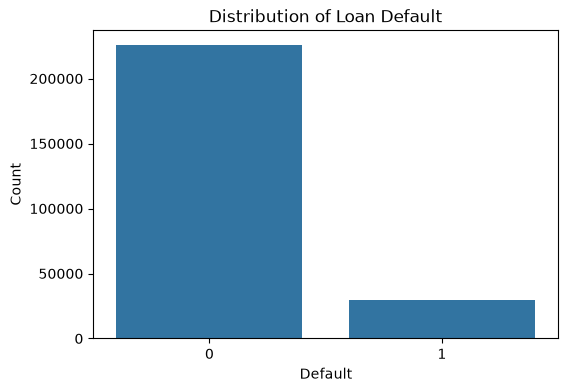

In [14]:
# ==========================================
# Target Variable Distribution
# ==========================================

plt.figure(figsize=(6,4))

sns.countplot(x="Default", data=df)

plt.title("Distribution of Loan Default")

plt.xlabel("Default")

plt.ylabel("Count")

plt.show()

## Observation

- The target variable is binary, making this a supervised binary classification problem.
- The majority of borrowers belong to the non-default class.
- The dataset appears to be (balanced / moderately imbalanced / highly imbalanced) based on the class distribution.
- Class imbalance will be examined further before model development.

# Key Findings

- The dataset contains 255,347 loan records and 18 variables.
- The target variable is `Default`, making this a binary classification problem.
- Both numerical and categorical variables are present.
- Missing values and duplicate records have been examined.
- The distribution of the target variable has been analyzed to assess class imbalance.
- The dataset is now ready for Exploratory Data Analysis (EDA).

In [1]:
categorical_cols = [
    "Education",
    "EmploymentType",
    "MaritalStatus",
    "HasMortgage",
    "HasDependents",
    "LoanPurpose",
    "HasCoSigner"
]

for col in categorical_cols:
    print(f"\n{col}:")
    print(sorted(df[col].unique()))


Education:


NameError: name 'df' is not defined